In [13]:
import pandas as pd
import numpy as np 
from sklearn.model_selection import train_test_split



X = np.array([
    [1],
    [2],
    [3],
    [4],
    [5],
    [6],
    [7],
    [8],
    [9],
    [10]
])

y = np.array([
    3,
    5,
    7,
    9,
    11,
    13,
    15,
    17,
    19,
    21
])

In [14]:

# ==========================================
# Stochastic Gradient Descent (SGD) Regression
# ==========================================

from sklearn.linear_model import SGDRegressor

# Create the SGD Regression model
sgd_reg = SGDRegressor(
    max_iter=1000,          # Maximum number of training epochs
    tol=1e-5,               # Stop if the improvement is smaller than 0.00001
    penalty=None,           # No regularization (No L1 or L2)
    eta0=0.01,              # Initial learning rate
    n_iter_no_change=100,   # Stop if there is no improvement for 100 epochs
    random_state=42         # Fix the random seed for reproducible results
)

# Train the model
# y.ravel() converts y from shape (n_samples, 1) to (n_samples,)
sgd_reg.fit(X, y.ravel())

# Print the learned parameters
print("Intercept (b):", sgd_reg.intercept_)
print("Coefficient (w):", sgd_reg.coef_)

Intercept (b): [0.92710494]
Coefficient (w): [2.01028248]


In [15]:
# =====================================================
# Polynomial Regression - Generate Nonlinear Dataset
# =====================================================

import numpy as np

# Create a random number generator.
# Using a fixed seed makes the results reproducible.
rng = np.random.default_rng(seed=42)

# Number of training samples
m = 200

# Generate random feature values between -3 and 3
# random() -> values in [0, 1)
# *6        -> values in [0, 6)
# -3        -> values in [-3, 3)
X = 6 * rng.random((m, 1)) - 3

# Generate target values using a quadratic function
# y = 0.5x² + x + 2

# Add Gaussian noise to simulate real-world data
y = 0.5 * X**2 + X + 2 + rng.standard_normal((m, 1))

# Display dataset shape
print("X shape:", X.shape)
print("y shape:", y.shape)

# -----------------------------------------------------
# Notes:
#
# - Linear Regression fits only a straight line.

# - Polynomial Regression handles nonlinear data by
#   creating new polynomial features (x², x³, ...).

# - The underlying model is still Linear Regression
#   because it is linear with respect to the parameters.

# - Gaussian noise makes the synthetic dataset more
#   realistic by adding random variations.
# -----------------------------------------------------

X shape: (200, 1)
y shape: (200, 1)


In [16]:
# =====================================================
# Polynomial Regression - Create Polynomial Features
# =====================================================

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Create polynomial features up to degree 2
# degree=2 creates: [x, x²]
# include_bias=False because LinearRegression already
# learns the intercept (bias) automatically.
poly_features = PolynomialFeatures(
    degree=2,
    include_bias=False
)

# Transform the original feature into polynomial features
X_poly = poly_features.fit_transform(X)

# Example:
print("Original Feature:")
print(X[0])

print("\nPolynomial Features:")
print(X_poly[0])

# Train a Linear Regression model on the transformed data
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)

# Display the learned parameters
print("\nIntercept (b):", lin_reg.intercept_)
print("Coefficients (w):", lin_reg.coef_)

# -----------------------------------------------------
# Notes:
#
# Original feature:
#     x
#
# Polynomial features (degree=2):
#     x
#     x²
#
# Learned equation:
#
# y = b + w1*x + w2*x²
#
# Polynomial Regression is still Linear Regression
# because it is linear with respect to the parameters,
# even though the relationship between x and y is nonlinear.
# -----------------------------------------------------

Original Feature:
[1.64373629]

Polynomial Features:
[1.64373629 2.701869  ]

Intercept (b): [2.00540719]
Coefficients (w): [[1.11022126 0.50526985]]


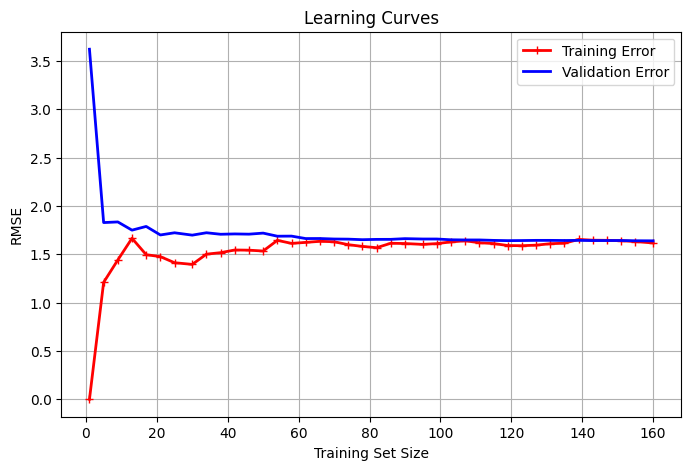

In [17]:
# =====================================================
# Learning Curves for Linear Regression
# =====================================================

from sklearn.model_selection import learning_curve
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# Compute learning curves using 5-fold cross-validation
train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(),
    X,
    y,
    train_sizes=np.linspace(0.01, 1.0, 40),   # Use 1% to 100% of the training data
    cv=5,                                     # 5-Fold Cross Validation
    scoring="neg_root_mean_squared_error"     # Negative RMSE
)

# Convert negative RMSE to positive RMSE
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

# Plot the learning curves
plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_errors,
         "r-+", linewidth=2, label="Training Error")

plt.plot(train_sizes, valid_errors,
         "b-", linewidth=2, label="Validation Error")

plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.title("Learning Curves")
plt.grid(True)
plt.legend()

plt.show()

# -----------------------------------------------------
# Notes:
#
# - Learning curves show model performance as the
#   training set size increases.
#
# - Training Error:
#   Error on the training dataset.
#
# - Validation Error:
#   Error on unseen validation data.
#
# - RMSE (Root Mean Squared Error):
#   Lower values indicate better performance.
#
# - If both errors are high -> Underfitting.
#
# - If training error is low but validation error is high
#   -> Overfitting.
#
# - A good model has low training and validation errors
#   that become close as more data is added.
# -----------------------------------------------------
# this data have overfitting problem

In [18]:
# =====================================================
# Bias-Variance Trade-off
# =====================================================

# Generalization Error consists of three components:
#
# Generalization Error =  Bias + Variance + Irreducible Error

# -----------------------------------------------------
# 1. Bias
# -----------------------------------------------------
# Bias is the error caused by incorrect assumptions.
# A high-bias model is too simple to capture the true
# relationship in the data.

# Example:
# Using Linear Regression to fit quadratic data.
#
# High Bias -> Underfitting
# - High training error
# - High validation error

# -----------------------------------------------------
# 2. Variance
# -----------------------------------------------------
# Variance measures how sensitive a model is to small
# changes in the training data.
#
# A very complex model (e.g., high-degree polynomial)
# may memorize the training data instead of learning
# the underlying pattern.

# High Variance -> Overfitting
# - Low training error
# - High validation error

# -----------------------------------------------------
# 3. Irreducible Error
# -----------------------------------------------------
# Error caused by noise in the data.
#
# Examples:
# - Measurement errors
# - Sensor noise
# - Incorrect labels
# - Outliers
#
# This error cannot be removed by choosing a better model.
# It can only be reduced by improving the data quality.

# -----------------------------------------------------
# Bias-Variance Trade-off
# -----------------------------------------------------
#
# Increasing model complexity:
#   ↓ Bias
#   ↑ Variance
#
# Decreasing model complexity:
#   ↑ Bias
#   ↓ Variance
#
# The goal is to find a balance that minimizes
# the total generalization error.

# -----------------------------------------------------
# Summary
#
# High Bias      -> Underfitting
# High Variance  -> Overfitting
# Good Model     -> Balance between Bias and Variance
# -----------------------------------------------------

In [19]:
# =====================================================
# Lasso Regression (L1 Regularization)
# =====================================================

from sklearn.linear_model import Lasso, SGDRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# -----------------------------------------------------
# Lasso Regression
# -----------------------------------------------------
# Lasso Regression adds an L1 regularization term
# to the Mean Squared Error (MSE) cost function.
#
# Cost Function:
#
# J(θ) = MSE(θ) + α * Σ|θ|
#
# Lasso keeps the model simple by shrinking weights.
# Unlike Ridge, it can shrink some weights exactly to zero.

# -----------------------------------------------------
# Feature Selection
# -----------------------------------------------------
# One of Lasso's main advantages is that it performs
# automatic feature selection.
#
# Features with zero coefficients are effectively removed
# from the model.

# -----------------------------------------------------
# Alpha (Regularization Strength)
# -----------------------------------------------------
# alpha = 0
#     Equivalent to Linear Regression.
#
# Small alpha
#     Weak regularization.
#
# Large alpha
#     Strong regularization.
#     More coefficients become zero.

# -----------------------------------------------------
# Feature Scaling
# -----------------------------------------------------
# Standardizing features before Lasso is recommended.

lasso_model = make_pipeline(
    StandardScaler(),
    Lasso(alpha=0.1)
)

lasso_model.fit(X, y)

prediction = lasso_model.predict([[1.5]])

print("Prediction:", prediction)

# Display learned coefficients
print("Intercept:", lasso_model.named_steps["lasso"].intercept_)
print("Coefficients:", lasso_model.named_steps["lasso"].coef_)

# -----------------------------------------------------
# Lasso Regression using SGD
# -----------------------------------------------------

m = len(X)

sgd_reg = SGDRegressor(
    penalty="l1",      # L1 Regularization
    alpha=0.1 / m,
    max_iter=1000,
    eta0=0.01,
    tol=None,
    random_state=42
)

sgd_reg.fit(X, y.ravel())

print("SGD Prediction:", sgd_reg.predict([[1.5]]))

# -----------------------------------------------------
# Summary
#
# Linear Regression:
#     No regularization.
#
# Ridge Regression:
#     Uses L2 regularization.
#     Keeps all features.
#
# Lasso Regression:
#     Uses L1 regularization.
#     Can shrink coefficients to exactly zero.
#     Performs automatic feature selection.
#
# Larger alpha:
#     Simpler model
#     Higher bias
#     Lower variance
# -----------------------------------------------------

Prediction: [4.97091437]
Intercept: [3.40772249]
Coefficients: [1.71866536]
SGD Prediction: [5.06210137]


In [20]:
# =====================================================
# Ridge Regression (L2 Regularization)
# =====================================================

from sklearn.linear_model import Ridge, SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# -----------------------------------------------------
# Ridge Regression
# -----------------------------------------------------
# Ridge Regression adds an L2 regularization term to the
# Mean Squared Error (MSE) cost function.
#
# Cost Function:
#
# J(θ) = MSE(θ) + α * Σ(θ²)
#
# The goal is to:
# - Fit the training data.
# - Keep the model weights as small as possible.
#
# Smaller weights reduce model complexity and help
# prevent overfitting.

# -----------------------------------------------------
# Alpha (Regularization Strength)
# -----------------------------------------------------
# alpha = 0
#     Equivalent to Linear Regression.
#
# Small alpha
#     Weak regularization.
#
# Large alpha
#     Strong regularization.
#     Weights move closer to zero.
#     The model becomes simpler.

# -----------------------------------------------------
# Important Note
# -----------------------------------------------------
# The bias (intercept) is NOT regularized.
# Only the feature weights are penalized.

# -----------------------------------------------------
# Feature Scaling
# -----------------------------------------------------
# Ridge Regression is sensitive to feature scales.
# Always standardize the data before training.

ridge_model = make_pipeline(
    StandardScaler(),
    Ridge(alpha=0.1)
)

ridge_model.fit(X, y)

prediction = ridge_model.predict([[1.5]])
print("Prediction:", prediction)

# -----------------------------------------------------
# Ridge Regression using SGD
# -----------------------------------------------------

m = len(X)

sgd_reg = SGDRegressor(
    penalty="l2",      # L2 Regularization (Ridge)
    alpha=0.1 / m,
    max_iter=1000,
    eta0=0.01,
    tol=None,
    random_state=42
)

sgd_reg.fit(X, y.ravel())

print("Prediction (SGD):", sgd_reg.predict([[1.5]]))

# -----------------------------------------------------
# Summary
#
# Linear Regression:
#     No regularization.
#
# Ridge Regression:
#     Uses L2 Regularization.
#     Keeps weights small.
#     Reduces overfitting.
#
# Larger alpha:
#     Simpler model
#     Higher bias
#     Lower variance
#
# Smaller alpha:
#     More complex model
#     Lower bias
#     Higher variance
# -----------------------------------------------------

Prediction: [5.06104154]
Prediction (SGD): [5.06208065]


In [21]:
# =====================================================
# Elastic Net Regression (L1 + L2 Regularization)
# =====================================================

from sklearn.linear_model import ElasticNet, SGDRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# -----------------------------------------------------
# Elastic Net Regression
# -----------------------------------------------------
# Elastic Net combines L1 (Lasso) and L2 (Ridge)
# regularization in a single model.
#
# Cost Function:
#
# J(θ) = MSE(θ)
#      + α * l1_ratio * Σ|θ|
#      + α * (1 - l1_ratio) / 2 * Σθ²
#
# Benefits:
# - Reduces overfitting.
# - Performs feature selection.
# - More stable than Lasso when features are correlated.

# -----------------------------------------------------
# Hyperparameters
# -----------------------------------------------------
# alpha:
#     Controls the overall regularization strength.
#
# l1_ratio:
#     0.0 -> Ridge Regression
#     1.0 -> Lasso Regression
#     0.5 -> Equal mix of L1 and L2

elastic_model = make_pipeline(
    StandardScaler(),
    ElasticNet(
        alpha=0.1,
        l1_ratio=0.5,
        random_state=42
    )
)

elastic_model.fit(X, y)

prediction = elastic_model.predict([[1.5]])

print("Prediction:", prediction)

# Display learned parameters
print("Intercept:",
      elastic_model.named_steps["elasticnet"].intercept_)

print("Coefficients:",
      elastic_model.named_steps["elasticnet"].coef_)

# -----------------------------------------------------
# Elastic Net using SGD
# -----------------------------------------------------

m = len(X)

sgd_reg = SGDRegressor(
    penalty="elasticnet",
    alpha=0.1 / m,
    l1_ratio=0.5,
    max_iter=1000,
    eta0=0.01,
    tol=None,
    random_state=42
)

sgd_reg.fit(X, y.ravel())

print("SGD Prediction:", sgd_reg.predict([[1.5]]))

# -----------------------------------------------------
# Summary
#
# Linear Regression
#     No regularization.
#
# Ridge Regression
#     L2 regularization.
#     Keeps all features.
#
# Lasso Regression
#     L1 regularization.
#     Performs feature selection.
#
# Elastic Net
#     Combination of L1 and L2.
#     Performs feature selection.
#     More stable with correlated features.
#
# alpha:
#     Controls regularization strength.
#
# l1_ratio:
#     0.0 -> Ridge
#     1.0 -> Lasso
#     Between 0 and 1 -> Elastic Net
# -----------------------------------------------------

Prediction: [4.93978801]
Intercept: [3.40772249]
Coefficients: [1.6844432]
SGD Prediction: [5.06209101]


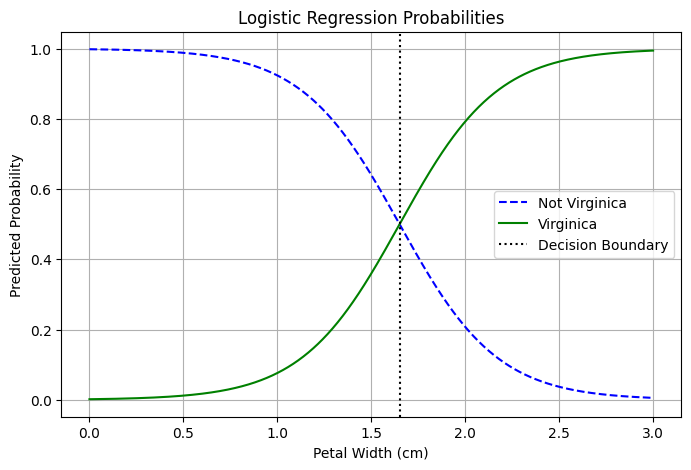

In [22]:
# =====================================================
# Logistic Regression - Binary Classification
# =====================================================

from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# Load the Iris dataset
iris = load_iris()

# Use petal width as the input feature
X = iris.data[:, [3]]   # Petal Width

# Binary target:
# True  -> Iris Virginica
# False -> Not Iris Virginica
y = (iris.target == 2)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42
)

# Train the Logistic Regression model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

# Generate new samples for visualization
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)

# Predict class probabilities
y_proba = log_reg.predict_proba(X_new)

# Find the decision boundary (Probability = 0.5)
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]

# Plot probabilities
plt.figure(figsize=(8,5))

plt.plot(
    X_new,
    y_proba[:,0],
    "b--",
    label="Not Virginica"
)

plt.plot(
    X_new,
    y_proba[:,1],
    "g-",
    label="Virginica"
)

plt.axvline(
    decision_boundary,
    color="black",
    linestyle=":",
    label="Decision Boundary"
)

plt.xlabel("Petal Width (cm)")
plt.ylabel("Predicted Probability")
plt.title("Logistic Regression Probabilities")
plt.grid(True)
plt.legend()

plt.show()

# -----------------------------------------------------
# Notes
#
# - Logistic Regression predicts probabilities.
#
# - predict_proba() returns:
#       Column 0 -> Probability of class 0
#       Column 1 -> Probability of class 1
#
# - The decision boundary is where:
#       P(class=1) = 0.5
#
# - predict() assigns the class with the
#   highest probability.
# -----------------------------------------------------

In [23]:
# =====================================================
# Softmax Regression (Multinomial Logistic Regression)
# =====================================================

from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Load Iris dataset
iris = load_iris()

# Use two input features
X = iris.data[:, (2, 3)]      # Petal Length, Petal Width

# Multi-class target
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42
)

# Train a Softmax Regression model
softmax_reg = LogisticRegression(random_state=42)
softmax_reg.fit(X_train, y_train)

softmax_reg.fit(X_train, y_train)

# Predict class
prediction = softmax_reg.predict([[5.0, 2.0]])

# Predict class probabilities
probabilities = softmax_reg.predict_proba([[5.0, 2.0]])

print("Predicted class:", prediction)
print("Class probabilities:")
print(probabilities)

# -----------------------------------------------------
# Notes
#
# - Softmax Regression extends Logistic Regression
#   to multi-class classification.
#
# - Each class has its own weight vector.
#
# - The model computes a score (logit) for each class.
#
# - The Softmax function converts scores into
#   probabilities.
#
# - The probabilities always sum to 1.
#
# - The predicted class is the one with the
#   highest probability (argmax).
#
# - Cross-Entropy Loss is used during training.
#
# - Softmax should be used only when classes are
#   mutually exclusive.
# -----------------------------------------------------

Predicted class: [2]
Class probabilities:
[[3.62393372e-04 2.39540179e-01 7.60097427e-01]]


In [24]:
# =====================================================
# Softmax Regression with Cross-Entropy Loss
# =====================================================

from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Load Iris dataset
iris = load_iris()

# Use two input features
X = iris.data[:, [2, 3]]      # Petal Length, Petal Width

# Multi-class labels
# 0 -> Setosa
# 1 -> Versicolor
# 2 -> Virginica
y = iris.target

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42
)

# Train Softmax Regression
# C controls regularization strength.
# Larger C -> Less regularization.
# Smaller C -> More regularization.
softmax_reg = LogisticRegression(
    C=30,
    random_state=42
)

softmax_reg.fit(X_train, y_train)

# Predict the class
prediction = softmax_reg.predict([[5, 2]])
print("Predicted class:", prediction)

# Predict class probabilities
probabilities = softmax_reg.predict_proba([[5, 2]])
print("Probabilities:", probabilities.round(2))

# -----------------------------------------------------
# Notes
#
# - Softmax Regression is used for multi-class
#   classification.
#
# - The model computes one score (logit)
#   for each class.
#
# - The Softmax function converts the scores
#   into probabilities.
#
# - The probabilities always sum to 1.
#
# - Cross-Entropy Loss is minimized during training.
#
# - The predicted class is simply the class with the
#   highest probability (argmax).
#
# - C is the inverse of regularization strength.
#
#       Large C  -> Less regularization
#       Small C  -> Stronger regularization
# -----------------------------------------------------

Predicted class: [2]
Probabilities: [[0.   0.04 0.96]]


In [25]:
# =====================================================
# Decision Tree Classification
# =====================================================

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# Load Iris dataset
iris = load_iris()

# Use two input features
X = iris.data[:, [2, 3]]      # Petal Length, Petal Width

# Multi-class labels
# 0 -> Setosa
# 1 -> Versicolor
# 2 -> Virginica
y = iris.target

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42
)

# Create Decision Tree model
# max_depth controls the maximum depth of the tree.
# Smaller depth -> Simpler model.
# Larger depth -> More complex model (may overfit).
tree_clf = DecisionTreeClassifier(
    max_depth=2,
    random_state=42,
    criterion="entropy"
)

# Train the model
tree_clf.fit(X_train, y_train)

# Predict the class
prediction = tree_clf.predict([[5, 2]])
print("Predicted class:", prediction)

# Predict class probabilities
probabilities = tree_clf.predict_proba([[5, 2]])
print("Probabilities:", probabilities.round(2))

# Calculate accuracy
accuracy = tree_clf.score(X_test, y_test)
print("Test Accuracy:", round(accuracy * 100, 2), "%")

# -----------------------------------------------------
# Notes
#
# - Decision Trees are supervised learning algorithms.
#
# - They can solve:
#       * Classification
#       * Regression
#
# - The model learns by asking a sequence of questions.
#
# - Each internal node represents a decision.
#
# - Each branch represents the answer to the question.
#
# - Each leaf node represents the final prediction.
#
# - max_depth limits how deep the tree can grow.
#
#       Small depth  -> Less overfitting
#       Large depth  -> Higher risk of overfitting
#
# - predict() returns the predicted class.
#
# - predict_proba() returns the probability
#   of each class.
#
# - score() returns the model accuracy.
# 
# samples هو عدد العينات الموجودة في العقدة.
# value يوضح عدد العينات من كل فئة داخل العقدة.
# class هو التصنيف الذي ستتنبأ به الشجرة (الفئة الأكثر عددًا).
# gini يقيس مدى نقاء العقدة:
#    0 يعني أن جميع العينات من نفس الفئة (نقاء تام).
#    كلما زادت القيمة، زاد اختلاط الفئات.
# -----------------------------------------------------

Predicted class: [2]
Probabilities: [[0.   0.12 0.88]]
Test Accuracy: 97.37 %


tensor([20, 21, 22, 23])


tensor(6.)
